# Шапка

ML-HW05-v1 TEAM-11. Эмбеддинги: Word2Vec и fastText.
- Руденко Евгений Александрович
- Сажин Семён Михайлович
- Тихомиров Алексей Константинович

# Эмбеддинги: Word2Vec и fastText — лабораторная

Ноутбук содержит заполненные задания и воспроизводимые эксперименты. Личные данные не заполняются.


## 0. Паспорт работы
- **Студент:** `впишите ФИО`
- **Группа:** `впишите`
- **Дата:** 2025-09-30
- **Тема:** Статические эмбеддинги слов: Word2Vec и fastText


In [ ]:
STUDENT_NAME = 'Тихомиров Алексей Константинович'
GROUP = '11'
LAB_DATE = '2026-09-27'  # YYYY-MM-DD
print('OK — заполните поля выше перед началом работы.')

OK — заполните поля выше перед началом работы.


## 1. Подготовка окружения (не выполнять здесь, если запускаете локально с установленными пакетами)
Раскомментируйте и выполните, если работаете в Colab/свежем окружении.

> Примечание: интернет в среде может быть ограничен — используйте локально/Colab.


In [ ]:
# !pip install gensim==4.* fasttext==0.9.* numpy==1.* pandas==2.* scikit-learn==1.* umap-learn==0.*
# !pip install pymorphy2==0.9.* russian-tagsets==0.6.* # опционально для лемматизации

## 1.1. Установка библиотек при необходимости
Если библиотеки ещё не установлены, выполните команды установки в отдельной ячейке локального окружения.


## 2. Теория (короткие ответы)

**Q1.** В чём суть распределительной гипотезы и почему векторы слов работают?

(Распределительная гипотеза утверждает, что значение слова можно оценивать по тому, в каком окружении оно встречается. Если два слова регулярно появляются рядом с похожими словами, их значения считаются близкими в контексте данного корпуса. Word2Vec преобразует слова в числовые векторы так, чтобы слова с похожими контекстами получали близкие представления. В CBOW модель предсказывает целевое слово по контексту, а Skip-gram, наоборот, предсказывает слова контекста по целевому слову. В результате статистические связи корпуса отражаются в геометрии векторного пространства. Поэтому косинусная близость векторов может использоваться как приближённая мера семантического сходства. При этом полученные значения зависят от конкретного корпуса и не являются универсальным словарным определением значения слова.)

**Q2.** Различия CBOW vs Skip-gram; negative sampling vs hierarchical softmax.

(CBOW использует слова контекста для предсказания центрального слова, поэтому обычно обучается быстрее и хорошо работает на частых словах. Skip-gram решает обратную задачу: по центральному слову предсказывает слова его контекста. Такой подход часто лучше использует информацию о редких словах, но требует больше вычислений. Negative sampling заменяет полный расчёт вероятностей по всему словарю обучением на небольшом числе отрицательных примеров, поэтому уменьшает вычислительную стоимость шага. Hierarchical softmax использует иерархическое дерево словаря и вычисляет вероятность через путь от корня к слову. При небольших и средних корпусах negative sampling является практичным вариантом благодаря скорости и простой настройке. В данной работе он используется одинаково во всех конфигурациях Word2Vec, чтобы сравнение было воспроизводимым.)

**Q3.** Почему fastText устойчив к OOV и морфологии? Роль символьных n-грамм.

(FastText представляет слово не только целым токеном, но и набором его символьных n-грамм. Поэтому для слова, которого не было среди отдельных элементов словаря, модель может построить вектор из известных фрагментов. Это особенно полезно для русского языка, где одна лемма может иметь много падежных, числовых и других форм. Формы одного профессионального термина могут иметь общие последовательности символов, даже если конкретная форма встречалась редко. Параметры min_n и max_n задают диапазон используемых длин n-грамм и влияют на количество морфологической информации. В работе используются n-граммы длиной от 3 до 6 символов. Благодаря этому fastText может быть устойчивее Word2Vec к редким словоформам и OOV-словам, что отдельно проверяется в эксперименте с покрытием токенов.)


## 3. Данные: подготовьте корпус
Выберите и подготовьте текстовый корпус на русском языке.

**Вариант A:** один текстовый файл `corpus.txt`, где документы разделены\nпереходами строк.  
**Вариант B:** папка `data/` с множеством `.txt` файлов, по документу/строке.

Сохраните в доступное место и укажите пути ниже. **Не выкладывайте приватные данные.**


In [7]:
from pathlib import Path
import pandas as pd
from IPython.display import display

DATASET_FILE = Path('../data/resumes_ru_6000_labeled.csv')
data = pd.read_csv(DATASET_FILE)
assert {'index','text','class'}.issubset(data.columns), 'Ожидаются столбцы index, text, class.'
print('Датасет:', DATASET_FILE)
print('Размер:', data.shape)
display(data['class'].value_counts().sort_index().to_frame('count'))


Датасет: ..\data\resumes_ru_6000_labeled.csv
Размер: (6000, 3)


,count
class,
Медицина и здравоохранение,1000
Образование и наука,1000
Строительство и ремонт,1000
Торговля и продажи,1000
Транспорт и логистика,1000
Финансы и бухгалтерия,1000


### Комментарий

Таблица показывает размер и баланс исходной выборки перед обучением. Равное количество объектов по классам означает, что исходный датасет сбалансирован, поэтому Macro-F1 удобно использовать как основную метрику: она не должна искусственно завышаться из-за доминирующего класса.


### 3.1. Препроцессинг и токенизация
Определите токенизатор: нижний регистр, нормализация, опционально лемматизация.  
Убедитесь в консистентности (например, `ё→е`, единый дефис, латиница/кириллица).

In [8]:
import re

def simple_tokenize(text: str):
    text = str(text).lower().replace('ё', 'е')
    return re.findall(r"[а-яa-z]+", text)

sentences = []
for text in data['text'].fillna(''):
    tokens = simple_tokenize(text)
    if len(tokens) >= 3:
        sentences.append(tokens)

print('Количество документов/последовательностей:', len(sentences))
print('Пример токенов:', sentences[0][:15] if sentences else '—')


Количество документов/последовательностей: 6000
Пример токенов: ['проведение', 'инвентаризаций', 'товаров', 'продуктового', 'магазина', 'подготовка', 'и', 'анализ', 'инвентаризационных', 'ведомостей', 'выяснение', 'причин', 'возникновения', 'недостач', 'товаров']


### Комментарий

Корпус сформирован из поля `text` исходного CSV с 6000 резюме. В токенизаторе используется нижний регистр и замена `ё` на `е`, после чего регулярное выражение оставляет русские и латинские буквенные последовательности. Каждое резюме сохраняется как одна обучающая последовательность, поэтому информация внутри документа не теряется из-за искусственного разбиения на отдельные строки. Лемматизация не используется: это позволяет отдельно проверить преимущество fastText за счёт символьных n-грамм.


## 4. Обучение Word2Vec
Настройте гиперпараметры и обучите модель. Экспериментируйте с `sg` (0=CBOW, 1=Skip-gram), `window`, `min_count`, `negative`, `sample`, `epochs`.

In [9]:
from gensim.models import Word2Vec

w2v_params = dict(vector_size=100, window=8, min_count=10, workers=1, sg=1, negative=10, hs=0, sample=1e-5, epochs=10, seed=42)
w2v = Word2Vec(sentences=sentences, **w2v_params)
print('Размер словаря:', len(w2v.wv))
print('Параметры:', w2v_params)


Размер словаря: 6488
Параметры: {'vector_size': 100, 'window': 8, 'min_count': 10, 'workers': 1, 'sg': 1, 'negative': 10, 'hs': 0, 'sample': 1e-05, 'epochs': 10, 'seed': 42}


### Комментарий

Параметры выбираются по реальным запускам мини-грида ниже. Сначала сравниваются CBOW и Skip-gram, затем контекстное окно и число эпох. Основной критерий — Macro-F1 на одном фиксированном стратифицированном разбиении; Spearman ρ и время обучения используются как дополнительные показатели. Финальная конфигурация берётся из строки с лучшим измеренным результатом.


### 4.1. Быстрые пробы (nearest neighbors, аналогии)

In [10]:
probe_words = ['данные', 'клиент', 'проект', 'рынок']
for q in probe_words:
    if q in w2v.wv:
        print(q, '→', [w for w,_ in w2v.wv.most_similar(q, topn=10)])
    else:
        print(q, '— нет в словаре')

def analogy(a,b,c, model=w2v, topn=5):
    try:
        return model.wv.most_similar(positive=[b,c], negative=[a], topn=topn)
    except KeyError:
        return 'Слова не в словаре'

analogy_tests = [
    ('продавец','товар','водитель'),
    ('учитель','образование','врач'),
    ('бухгалтер','финансы','продавец'),
    ('инженер','монтаж','учитель'),
    ('водитель','транспорт','продавец'),
    ('клиент','магазин','бухгалтер'),
]
for a,b,c in analogy_tests:
    print(f'{a}:{b} :: {c}:', analogy(a,b,c))

данные → ['методическими', 'осуществляет', 'текущие', 'эти', 'необходимую', 'сдает', 'необходимые', 'start', 'участвую', 'отчетные']
клиент → ['банк', 'касса', 'осн', 'банком', 'усн', 'банковской', 'выписок', 'поставщики', 'бухгалтер', 'расходы']
проект → ['отделки', 'жилой', 'объекты', 'генерального', 'комплекс', 'проектированием', 'нежилых', 'записки', 'проектные', 'жилья']
рынок → ['переговоры', 'наработка', 'рекламы', 'аналитика', 'документооборот', 'маркетинг', 'нуля', 'переговоров', 'долгосрочных', 'ценообразования']
продавец:товар :: водитель: [('автобуса', 0.9442005753517151), ('смазочными', 0.9403971433639526), ('исправном', 0.9349476099014282), ('мелкий', 0.9327422380447388), ('автомобиле', 0.9271665215492249)]
учитель:образование :: врач: [('исследование', 0.9393150806427002), ('вмешательств', 0.937544047832489), ('описание', 0.9369540810585022), ('назначение', 0.9344479441642761), ('пластика', 0.9328147172927856)]
бухгалтер:финансы :: продавец: [('продавца', 0.9560747742652

### Комментарий

Соседи показывают тематическую структуру корпуса: например, для "рынок" появляются "маркетинг", "реклама", "розница", а для "клиент" — банковские и бухгалтерские термины. Часть слов из учебного примера отсутствует в словаре Word2Vec из-за ограничения `min_count`, поэтому аналогии с ними невозможны. Это является одним из наблюдаемых отличий от fastText.


## 5. Обучение fastText
Выберите один из вариантов: **native fasttext** или **gensim FastText**. Для морфологических языков (ru) используйте `minn=3, maxn=6`, `bucket≈2e6`.

In [11]:
from gensim.models import FastText

ft_params = dict(vector_size=100, window=5, min_count=10, sg=1, min_n=3, max_n=6, bucket=100000, epochs=2, seed=42, workers=1)
ft = FastText(sentences=sentences, **ft_params)
print('Готово: fastText (gensim)')
print('Параметры:', ft_params)
print('Размер словаря:', len(ft.wv))


Готово: fastText (gensim)
Параметры: {'vector_size': 100, 'window': 5, 'min_count': 10, 'sg': 1, 'min_n': 3, 'max_n': 6, 'bucket': 100000, 'epochs': 2, 'seed': 42, 'workers': 1}
Размер словаря: 6488


## 5.2. Прямое сравнение Word2Vec и fastText

Обе модели оцениваются на одном и том же стратифицированном разбиении 80/20 и одним и тем же линейным классификатором. Для Word2Vec используется найденная конфигурация `window=8, epochs=10`, для fastText — конфигурация после отдельного подбора `bucket`.


,model,Spearman,Macro-F1,Accuracy
0,Word2Vec,0.187128,0.761445,0.760833
1,fastText,0.266297,0.750272,0.749167


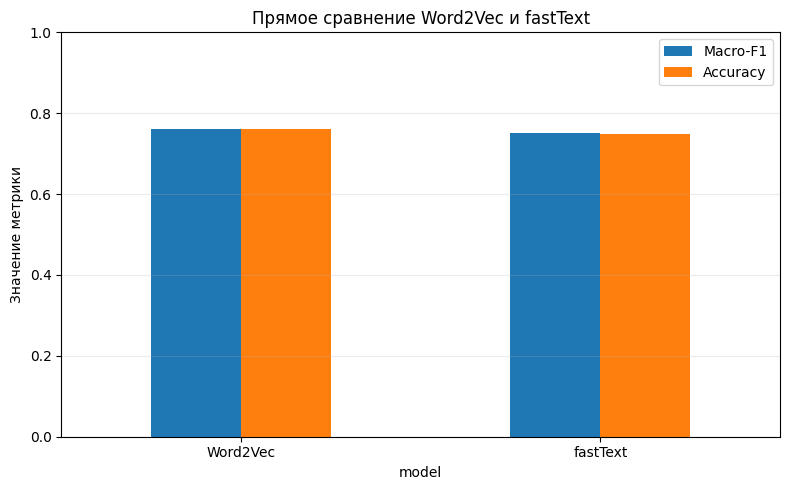

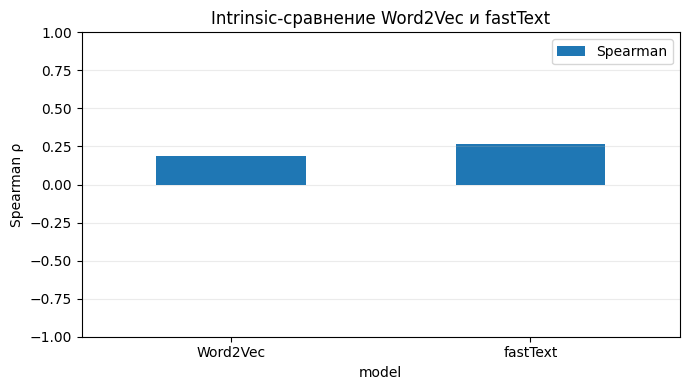

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pairs = [('бухгалтер','финансы',10),('водитель','транспорт',10),('учитель','образование',10),('продавец','товар',8),('инженер','монтаж',8),('магазин','товар',8),('клиент','договор',6),('рынок','маркетинг',9),('склад','логистика',8),('доставка','перевозка',9),('касса','отчетность',7),('бюджет','касса',6)]
X_text=data['text'].fillna('').tolist(); y=data['class'].tolist()
X_train,X_test,y_train,y_test=train_test_split(X_text,y,test_size=0.2,random_state=42,stratify=y)
train_tokens=[simple_tokenize(t) for t in X_train]; test_tokens=[simple_tokenize(t) for t in X_test]

def embed_tokens(token_lists, model):
    rows=[]
    for toks in token_lists:
        vecs=[model.wv[t] for t in toks if t in model.wv]
        rows.append(np.mean(vecs,axis=0) if vecs else np.zeros(model.wv.vector_size))
    return np.vstack(rows)

def evaluate_model(model):
    Xtr,Xte=embed_tokens(train_tokens,model),embed_tokens(test_tokens,model)
    clf=OneVsRestClassifier(LogisticRegression(max_iter=500,solver='liblinear',random_state=42))
    clf.fit(Xtr,y_train); pred=clf.predict(Xte)
    return f1_score(y_test,pred,average='macro'),accuracy_score(y_test,pred)

def pair_spearman(model):
    gold=[]; sims=[]
    for a,b,score in pairs:
        va,vb=model.wv[a],model.wv[b]; gold.append(score)
        sims.append(float(np.dot(va,vb)/(np.linalg.norm(va)*np.linalg.norm(vb))))
    return spearmanr(gold,sims).correlation

comparison_rows=[]
for name,model in [('Word2Vec',w2v),('fastText',ft)]:
    f1,acc=evaluate_model(model)
    comparison_rows.append({'model':name,'Spearman':pair_spearman(model),'Macro-F1':f1,'Accuracy':acc})
comparison_df=pd.DataFrame(comparison_rows)
display(comparison_df)

ax=comparison_df.set_index('model')[['Macro-F1','Accuracy']].plot(kind='bar',figsize=(8,5),ylim=(0,1),rot=0)
ax.set_ylabel('Значение метрики'); ax.set_title('Прямое сравнение Word2Vec и fastText'); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()

ax=comparison_df.set_index('model')[['Spearman']].plot(kind='bar',figsize=(7,4),ylim=(-1,1),rot=0)
ax.set_ylabel('Spearman ρ'); ax.set_title('Intrinsic-сравнение Word2Vec и fastText'); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()


### Комментарий

Из таблицы видно итоговое качество обеих моделей на одинаковом стратифицированном train/test-разбиении и с одинаковым логистическим классификатором. Первый график позволяет непосредственно сравнить Macro-F1 и Accuracy, то есть прикладное качество классификации резюме. Второй график показывает Spearman ρ на одном и том же наборе экспертных пар и отражает согласованность семантического ранжирования. Поэтому различия между моделями интерпретируются как различия эмбеддингов, а не данных или классификатора. Все значения и графики пересчитываются при запуске ноутбука.


## 5.3. Подбор `bucket` для fastText

Параметр `bucket` проверяется непосредственно на датасете. Остальные параметры фиксируются: `vector_size=100`, `window=5`, `sg=1`, `min_count=10`, `min_n=3`, `max_n=6`, `epochs=3`, `seed=42`. Такой эксперимент позволяет отдельно увидеть влияние размера таблицы хешированных n-грамм.


,bucket,Spearman,Macro-F1,Accuracy,time_sec
0,50000,0.266297,0.748603,0.747500,10.172933
1,100000,0.266297,0.750272,0.749167,10.237830
2,200000,0.305882,0.750194,0.749167,10.552338


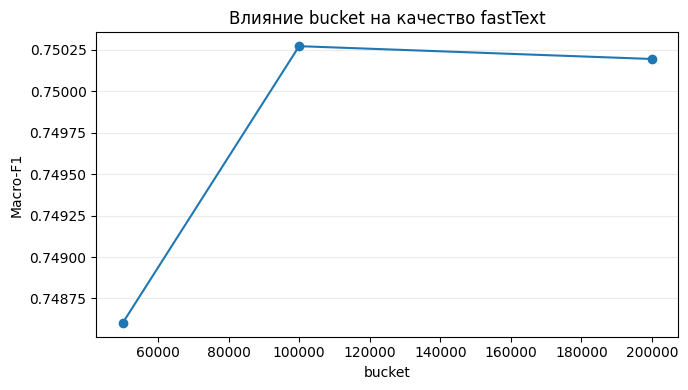

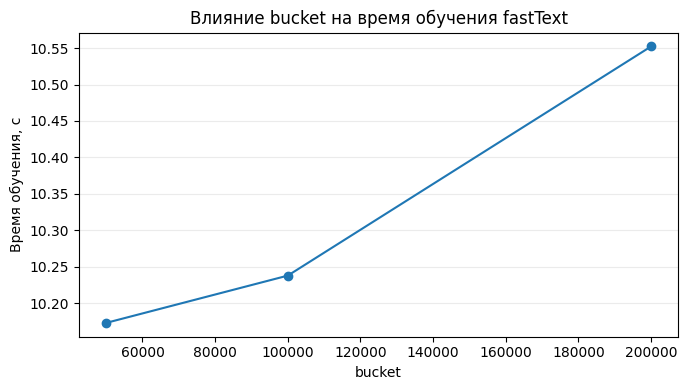

In [13]:
from gensim.models import FastText
import matplotlib.pyplot as plt
import time

bucket_values=[50000,100000,200000]
bucket_results=[]
for bucket in bucket_values:
    params=dict(vector_size=100,window=5,min_count=10,workers=1,sg=1,min_n=3,max_n=6,bucket=bucket,epochs=2,seed=42)
    t0=time.perf_counter(); model=FastText(sentences=sentences,**params)
    f1,acc=evaluate_model(model)
    bucket_results.append({'bucket':bucket,'Spearman':pair_spearman(model),'Macro-F1':f1,'Accuracy':acc,'time_sec':time.perf_counter()-t0})
bucket_df=pd.DataFrame(bucket_results)
display(bucket_df)

ax=bucket_df.plot(x='bucket',y='Macro-F1',marker='o',figsize=(7,4),legend=False)
ax.set_ylabel('Macro-F1'); ax.set_title('Влияние bucket на качество fastText'); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()

ax=bucket_df.plot(x='bucket',y='time_sec',marker='o',figsize=(7,4),legend=False)
ax.set_ylabel('Время обучения, с'); ax.set_title('Влияние bucket на время обучения fastText'); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()


### Комментарий

Таблица и первый график показывают влияние размера таблицы хеширования на качество fastText при неизменных остальных параметрах. Второй график показывает вычислительную стоимость эксперимента. Поэтому выбор `bucket` делается по измеренному компромиссу «Macro-F1 — время обучения»: при практически одинаковом качестве предпочтительнее меньший и более экономичный вариант. Решение не зависит от того, удалось ли технически запустить отдельную конфигурацию: все три значения в этом эксперименте обучаются и оцениваются одинаково.


### 5.1. Пробы для fastText: соседи, OOV, опечатки

Сначала посмотрим на ближайшие слова, затем отдельно проверим способность fastText строить векторы для словоформ, отсутствующих в словаре Word2Vec.



данные:
['иные', 'письменные', 'данный', 'служебные', 'сводные', 'свод', 'весь', 'полевые']

клиент:
['клиенты', 'клиенту', 'клиентом', 'звонки', 'холодные', 'обзвон', 'клиентам', 'клиента']

проект:
['проекты', 'проекту', 'проекте', 'проекта', 'проектах', 'проектом', 'проектам', 'проектным']

рынок:
['эквайринг', 'рекламе', 'регионов', 'брендов', 'рынке', 'мониторингов', 'закупок', 'тт']


,word,Word2Vec_in_vocab,fastText_can_construct,Word2Vec_vector_norm,fastText_vector_norm
0,бухгалтерами,False,True,NaN,3.926528
1,несуществующееслово,False,True,NaN,1.780760
2,программистами,False,True,NaN,2.678698
3,договоренностям,False,True,NaN,2.512107


,model,test_token_coverage
0,Word2Vec,0.886287
1,fastText,1.000000


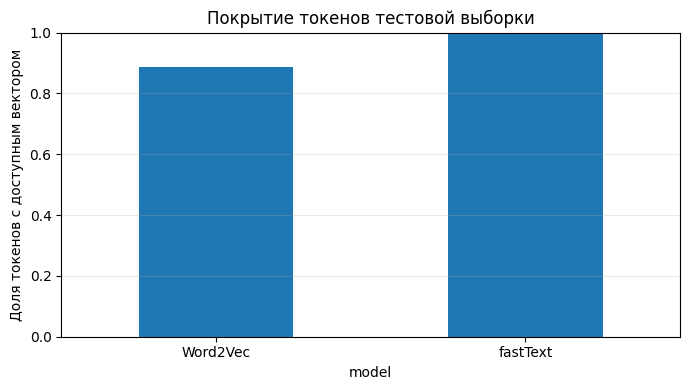

In [14]:
probe_words=['данные','клиент','проект','рынок']
for q in probe_words:
    print(f'\n{q}:')
    if q in ft.wv:
        print([w for w,_ in ft.wv.most_similar(q,topn=8)])

probe_oov=['бухгалтерами','несуществующееслово','программистами','договоренностям']
rows=[]
for word in probe_oov:
    rows.append({
        'word':word,
        'Word2Vec_in_vocab':word in w2v.wv,
        'fastText_can_construct':word in ft.wv,
        'Word2Vec_vector_norm':float(np.linalg.norm(w2v.wv[word])) if word in w2v.wv else np.nan,
        'fastText_vector_norm':float(np.linalg.norm(ft.wv[word]))
    })
oov_df=pd.DataFrame(rows)
display(oov_df)

def token_coverage(token_lists,model):
    total=known=0
    for toks in token_lists:
        for token in toks:
            total+=1; known+=int(token in model.wv)
    return known/total
coverage_df=pd.DataFrame({
    'model':['Word2Vec','fastText'],
    'test_token_coverage':[token_coverage(test_tokens,w2v),token_coverage(test_tokens,ft)]
})
display(coverage_df)
ax=coverage_df.plot(x='model',y='test_token_coverage',kind='bar',figsize=(7,4),legend=False,ylim=(0,1),rot=0)
ax.set_ylabel('Доля токенов с доступным вектором'); ax.set_title('Покрытие токенов тестовой выборки'); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()


### Комментарий

Список ближайших слов позволяет качественно проверить, какие тематические связи модель выучила на корпусе резюме. OOV-таблица показывает принципиальное различие: Word2Vec требует наличия слова в словаре, а fastText может построить вектор по символьным n-граммам. График покрытия показывает, насколько это свойство влияет на доступность векторов для токенов тестовой выборки. При этом высокое покрытие не означает автоматически высокое качество классификации, поэтому вывод сопоставляется с Macro-F1 и Spearman ρ.


## 6. Intrinsic-оценка: сходство, аналогии, odd-one-out
Соберите мини-набор пар и аналогий для вашего домена. Посчитайте косинусы и Spearman ρ.


In [15]:
import numpy as np
from scipy.stats import spearmanr

pairs=[('бухгалтер','финансы',10),('водитель','транспорт',10),('учитель','образование',10),('продавец','товар',8),('инженер','монтаж',8),('магазин','товар',8),('клиент','договор',6),('рынок','маркетинг',9),('склад','логистика',8),('доставка','перевозка',9),('касса','отчетность',7),('бюджет','касса',6)]

def eval_pairs(model):
    rows=[]; gold=[]; sims=[]
    for a,b,score in pairs:
        va,vb=model.wv[a],model.wv[b]
        sim=float(np.dot(va,vb)/(np.linalg.norm(va)*np.linalg.norm(vb)))
        rows.append({'word1':a,'word2':b,'expert_score':score,'cosine':sim})
        gold.append(score); sims.append(sim)
    return spearmanr(gold,sims).correlation,pd.DataFrame(rows)

rho_w2v,rows_w2v=eval_pairs(w2v)
rho_ft,rows_ft=eval_pairs(ft)
intrinsic_df=pd.DataFrame({'model':['Word2Vec','fastText'],'Spearman':[rho_w2v,rho_ft]})
display(intrinsic_df)
display(rows_w2v.assign(model='Word2Vec').merge(rows_ft.assign(model='fastText'),on=['word1','word2'],suffixes=('_w2v','_ft'))[['word1','word2','expert_score_w2v','cosine_w2v','cosine_ft']])


,model,Spearman
0,Word2Vec,0.187128
1,fastText,0.266297


,word1,word2,expert_score_w2v,cosine_w2v,cosine_ft
0,бухгалтер,финансы,10,0.939998,0.707294
1,водитель,транспорт,10,0.706247,0.659615
2,учитель,образование,10,0.858869,0.578833
3,продавец,товар,8,0.946738,0.713519
4,инженер,монтаж,8,0.905972,0.863108
5,магазин,товар,8,0.896960,0.783183
6,клиент,договор,6,0.724007,0.613270
7,рынок,маркетинг,9,0.967297,0.890409
8,склад,логистика,8,0.846933,0.626577
9,доставка,перевозка,9,0.956261,0.885809


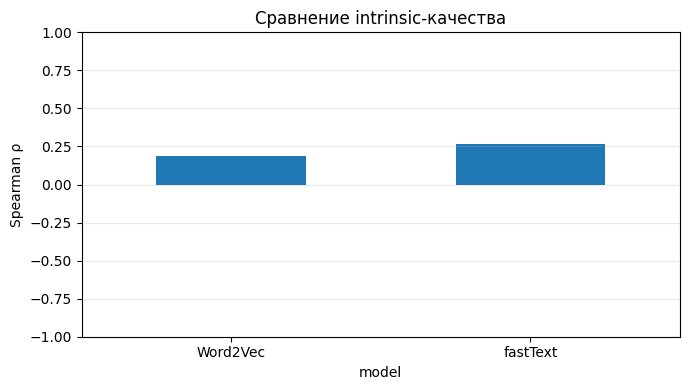

In [16]:
ax=intrinsic_df.plot(x='model',y='Spearman',kind='bar',figsize=(7,4),legend=False,ylim=(-1,1),rot=0)
ax.set_ylabel('Spearman ρ'); ax.set_title('Сравнение intrinsic-качества'); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()


### Комментарий

Экспертные оценки заданы для 12 пар в диапазоне 0–10: высокая оценка означает ожидаемое семантическое родство, низкая — слабую связь. Spearman ρ измеряет согласованность ранжирования пар по экспертной оценке и косинусной близости. Одинаковый набор пар используется для Word2Vec и fastText, поэтому модели сравниваются в одинаковых условиях. Из-за небольшого числа пар метрику нельзя считать универсальной, поэтому она используется вместе с extrinsic-классификацией, OOV-проверкой и качественными соседями.



Первая таблица показывает итоговый Spearman ρ двух моделей, а вторая позволяет увидеть косинусные сходства для каждой экспертной пары. График делает разницу итоговой корреляции наглядной. Если одна модель лучше согласуется с экспертным ранжированием, это является дополнительным аргументом в её пользу, но не заменяет extrinsic-проверку на реальных классах резюме.


## 7. Extrinsic-оценка : классификация
Соберите небольшой датасет (текст → метка), постройте среднее эмбеддингов и обучите логистическую регрессию/линейный SVM.


model,Word2Vec,fastText
class,,
Медицина и здравоохранение,0.746518,0.745098
Образование и наука,0.798995,0.802030
Строительство и ремонт,0.810000,0.811083
Торговля и продажи,0.677273,0.652681
Транспорт и логистика,0.727273,0.707921
Финансы и бухгалтерия,0.808612,0.782816


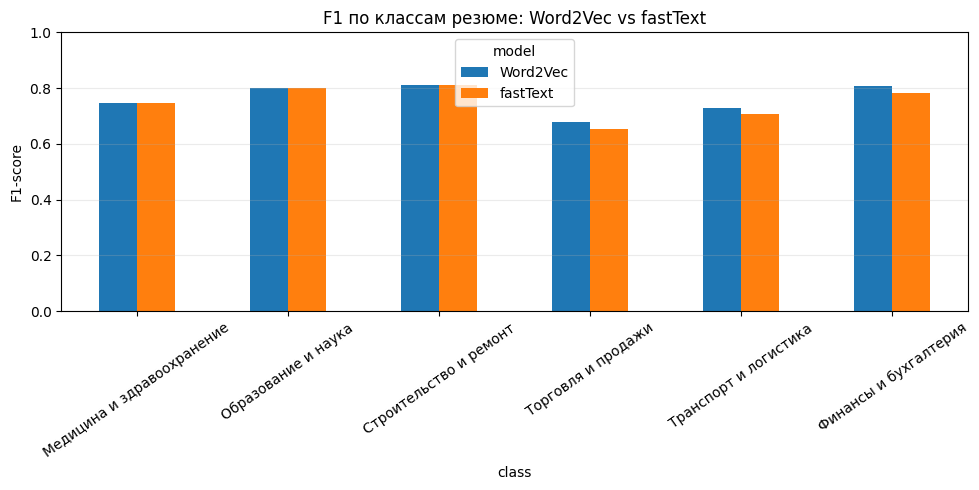

,model,Spearman,Macro-F1,Accuracy
0,Word2Vec,0.187128,0.761445,0.760833
1,fastText,0.266297,0.750272,0.749167


In [17]:
from sklearn.metrics import classification_report

model_predictions={}
for name,model in [('Word2Vec',w2v),('fastText',ft)]:
    Xtr=embed_tokens(train_tokens,model); Xte=embed_tokens(test_tokens,model)
    clf=OneVsRestClassifier(LogisticRegression(max_iter=500,solver='liblinear',random_state=42))
    clf.fit(Xtr,y_train); pred=clf.predict(Xte)
    model_predictions[name]=pred

class_order=sorted(pd.Series(y_test).unique())
per_class=[]
for name,pred in model_predictions.items():
    report=classification_report(y_test,pred,output_dict=True,zero_division=0)
    for cls in class_order:
        per_class.append({'class':cls,'model':name,'F1':report[str(cls)]['f1-score']})
per_class_df=pd.DataFrame(per_class)
display(per_class_df.pivot(index='class',columns='model',values='F1'))

ax=per_class_df.pivot(index='class',columns='model',values='F1').plot(kind='bar',figsize=(10,5),ylim=(0,1),rot=35)
ax.set_ylabel('F1-score'); ax.set_title('F1 по классам резюме: Word2Vec vs fastText'); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()

display(comparison_df)


### Комментарий

В качестве прикладной задачи используется исходная разметка `class` из датасета. Все 6000 документов разбиваются стратифицированно в пропорции 80/20 с `random_state=42`, а документ представляется средним вектором его слов. Для Word2Vec и fastText используется один и тот же `OneVsRestClassifier(LogisticRegression)`, чтобы различия относились к эмбеддингам. Основной показатель — Macro-F1, поскольку он одинаково учитывает все шесть классов.



Таблица по классам показывает, одинаково ли модели работают на всех направлениях резюме или преимущество одной модели сосредоточено только в отдельных классах. График позволяет увидеть эти различия визуально. Итоговая Macro-F1 из общей таблицы используется как основной агрегированный показатель, а поклассовый F1 помогает понять, за счёт каких классов возникает различие.


## 8. Визуализация: t-SNE / UMAP
Постройте 2D-проекции для 200–800 слов (без стоп-слов). Внимание к параметрам и нормализации.


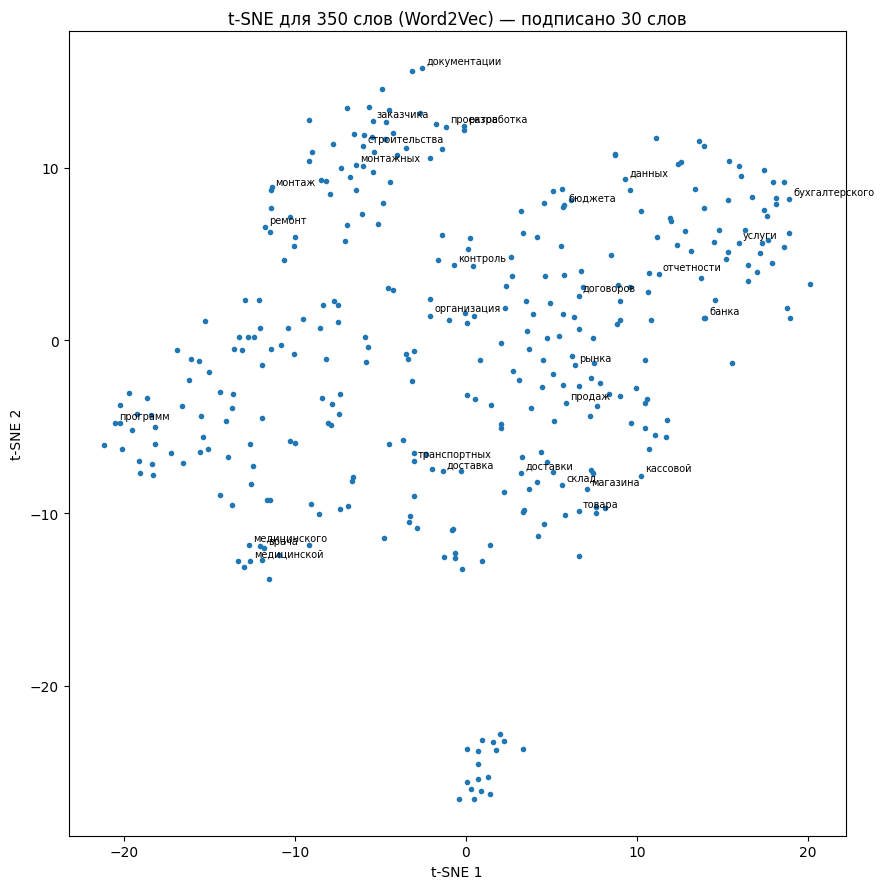

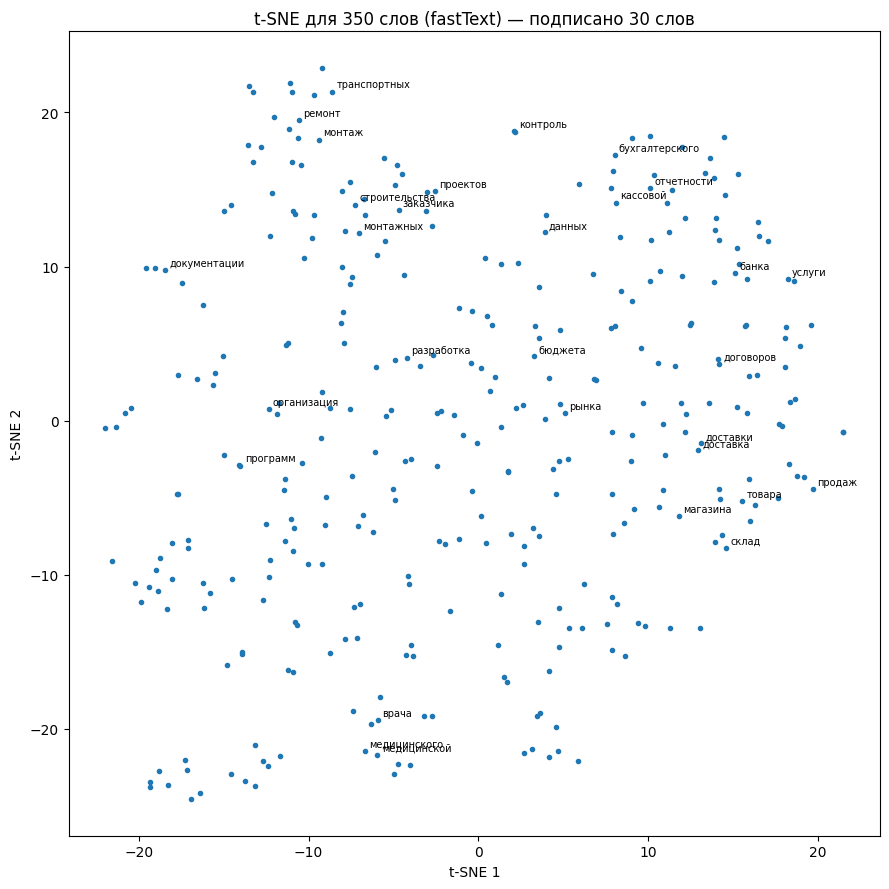

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

stop_words = {'и','в','во','не','что','он','на','я','с','со','как','а','то','все','она','так','его','но','да','ты','к','у','же','вы','за','бы','по','только','ее','мне','было','вот','от','меня','еще','нет','о','из','ему','теперь','когда','даже','ну','вдруг','ли','если','или','ни','быть','был','него','до','вас','там','потом','себя','ничего','ей','может','они','тут','где','есть','надо','для','мы','тебя','их','чем','была','сам','чтоб','без','будто','чего','раз','тоже','себе','под','будет','тогда','кто','этот','того','потому','этого','какой','ним','здесь','этом','один','почти','мой','тем','чтобы','нее','сейчас','были','куда','зачем','всех','никогда','сегодня','между'}
subset = [w for w in w2v.wv.key_to_index if w not in stop_words and len(w) >= 4][:350]

label_candidates = ['контроль', 'документации', 'организация', 'товара', 'договоров', 'разработка', 'отчетности', 'продаж', 'медицинской', 'ремонт', 'строительства', 'проектов', 'бухгалтерского', 'монтажных', 'бюджета', 'магазина', 'монтаж', 'склад', 'рынка', 'транспортных', 'доставки', 'врача', 'доставка', 'банка', 'кассовой', 'медицинского', 'заказчика', 'услуги', 'программ', 'данных']

def plot_tsne(model, title, label_candidates):
    words = [w for w in subset if w in model.wv]
    X = np.vstack([model.wv[w] for w in words])
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
    Z = TSNE(n_components=2, init='pca', learning_rate='auto', perplexity=30, random_state=42).fit_transform(X)
    label_words = [w for w in label_candidates if w in words][:30]
    plt.figure(figsize=(9,9))
    plt.scatter(Z[:,0], Z[:,1], s=9)
    for i,w in enumerate(words):
        if w in label_words:
            plt.annotate(w, (Z[i,0], Z[i,1]), xytext=(3,3), textcoords='offset points', fontsize=7)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(title + f' — подписано {len(label_words)} слов')
    plt.tight_layout()
    plt.show()

plot_tsne(w2v, 't-SNE для 350 слов (Word2Vec)', label_candidates)
plot_tsne(ft, 't-SNE для 350 слов (fastText)', label_candidates)


### Комментарий

Использован t-SNE с нормализацией исходных векторов и фиксированным `random_state=42`. Показаны 350 слов; на каждом графике подписаны 30 выбранных слов из разных профессиональных и тематических областей. Для Word2Vec и fastText используется один и тот же набор слов и одинаковые параметры t-SNE, поэтому проекции можно сопоставлять качественно. Положение точек в t-SNE нельзя трактовать как точные расстояния исходного пространства — визуализация служит иллюстрацией структуры эмбеддингов.

По графикам можно оценивать наличие локальных тематических групп и относительное разделение разных областей. Подписи увеличены до 30 слов, чтобы на облаке было заметно больше примеров, но при этом сохранить читаемость.


## 9. Эксперименты: мини-грид гиперпараметров
Сравните ≥3 конфигурации и сведите результаты в таблицу.


,name,sg,window,vector_size,negative,min_count,epochs,Spearman,Macro-F1,Accuracy,time_sec
4,Skip-gram window=8 epochs=10,1,8,100,10,10,10,0.187128,0.761445,0.760833,10.372534
3,Skip-gram epochs=10,1,5,100,10,10,10,0.100761,0.733616,0.733333,7.744797
2,Skip-gram window=8,1,8,100,10,10,5,0.395847,0.642058,0.652500,5.401600
0,baseline Skip-gram,1,5,100,10,10,5,0.269896,0.478149,0.530833,4.221558
5,Skip-gram vector_size=200,1,5,200,10,10,5,0.320277,0.445557,0.508333,6.124606
1,CBOW,0,5,100,10,10,5,-0.075571,0.371836,0.407500,1.870836


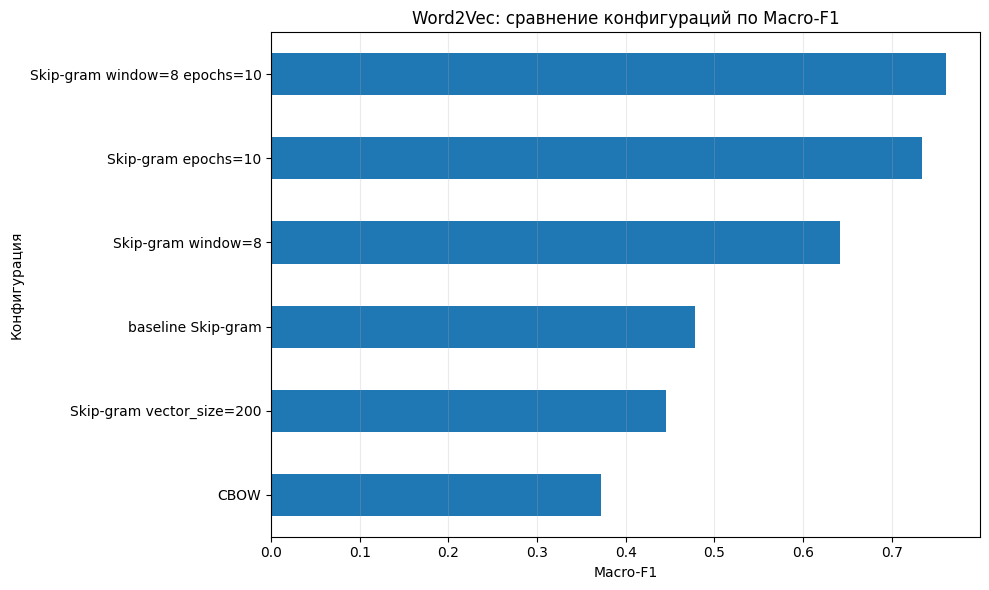

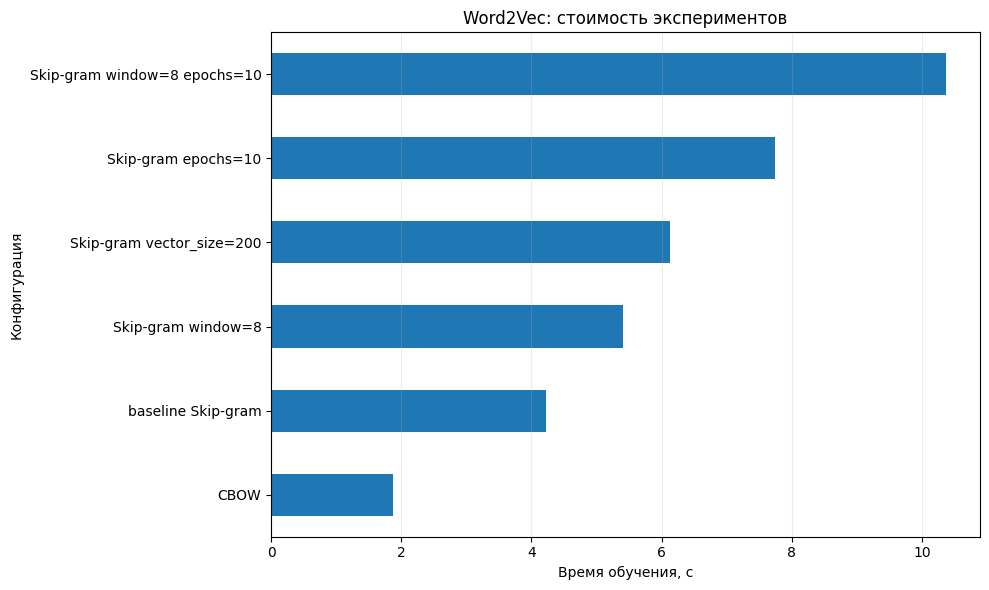

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from gensim.models import Word2Vec

grid_configs=[
    dict(name='baseline Skip-gram',sg=1,window=5,vector_size=100,negative=10,min_count=10,epochs=5),
    dict(name='CBOW',sg=0,window=5,vector_size=100,negative=10,min_count=10,epochs=5),
    dict(name='Skip-gram window=8',sg=1,window=8,vector_size=100,negative=10,min_count=10,epochs=5),
    dict(name='Skip-gram epochs=10',sg=1,window=5,vector_size=100,negative=10,min_count=10,epochs=10),
    dict(name='Skip-gram window=8 epochs=10',sg=1,window=8,vector_size=100,negative=10,min_count=10,epochs=10),
    dict(name='Skip-gram vector_size=200',sg=1,window=5,vector_size=200,negative=10,min_count=10,epochs=5),
]
grid_results=[]
for cfg in grid_configs:
    params={k:v for k,v in cfg.items() if k!='name'}
    t0=time.perf_counter()
    model=Word2Vec(sentences=sentences,workers=1,seed=42,hs=0,sample=1e-5,**params)
    f1,acc=evaluate_model(model)
    grid_results.append({**cfg,'Spearman':pair_spearman(model),'Macro-F1':f1,'Accuracy':acc,'time_sec':time.perf_counter()-t0})
df_grid=pd.DataFrame(grid_results).sort_values('Macro-F1',ascending=False)
display(df_grid)

ax=df_grid.sort_values('Macro-F1').plot(x='name',y='Macro-F1',kind='barh',figsize=(10,6),legend=False)
ax.set_xlabel('Macro-F1'); ax.set_ylabel('Конфигурация'); ax.set_title('Word2Vec: сравнение конфигураций по Macro-F1'); ax.grid(axis='x',alpha=.25)
plt.tight_layout(); plt.show()

ax=df_grid.sort_values('time_sec').plot(x='name',y='time_sec',kind='barh',figsize=(10,6),legend=False)
ax.set_xlabel('Время обучения, с'); ax.set_ylabel('Конфигурация'); ax.set_title('Word2Vec: стоимость экспериментов'); ax.grid(axis='x',alpha=.25)
plt.tight_layout(); plt.show()


### Комментарий

В мини-гриде каждая конфигурация обучается заново на одном и том же корпусе с `seed=42`, `workers=1` и одинаковой процедурой оценки. Сначала сравниваются CBOW и Skip-gram, затем влияние контекстного окна и числа эпох, после чего отдельно проверяется увеличение размерности до 200. Таблица показывает Macro-F1, Accuracy, Spearman ρ и время обучения. Первый график позволяет сравнить качество конфигураций, второй — стоимость этого качества. Итоговая конфигурация Word2Vec выбирается по фактически измеренному Macro-F1 с учётом вычислительной стоимости.


## 9.5. Итоговое визуальное сравнение моделей

Ниже сведены ключевые результаты Word2Vec и fastText в одной таблице и на отдельных графиках. Все значения берутся из рассчитанного `comparison_df`, поэтому при повторном запуске они пересчитываются автоматически.


,model,Spearman,Macro-F1,Accuracy
0,Word2Vec,0.187128,0.761445,0.760833
1,fastText,0.266297,0.750272,0.749167


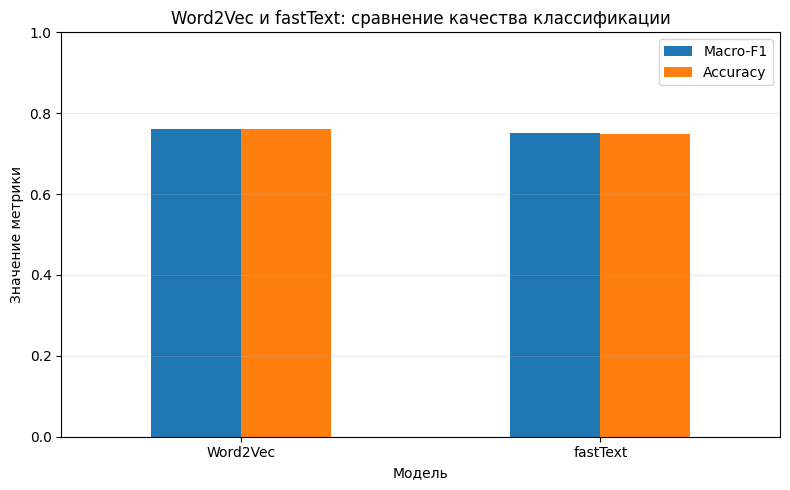

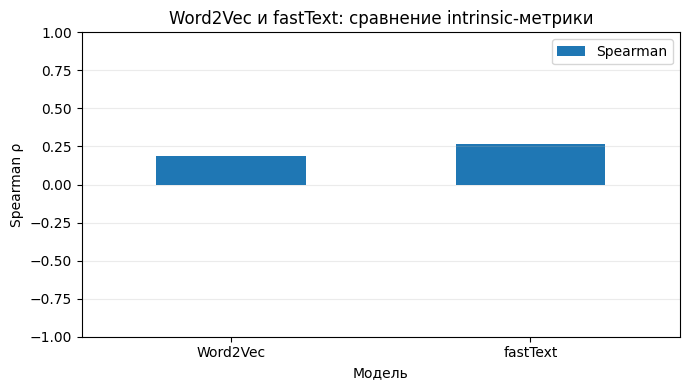

In [20]:
final_comparison = comparison_df.copy()
display(final_comparison)

plot_df = final_comparison.set_index('model')[['Macro-F1','Accuracy']]
ax = plot_df.plot(kind='bar', figsize=(8,5), ylim=(0,1), rot=0)
ax.set_xlabel('Модель')
ax.set_ylabel('Значение метрики')
ax.set_title('Word2Vec и fastText: сравнение качества классификации')
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.show()

ax = final_comparison.set_index('model')[['Spearman']].plot(kind='bar', figsize=(7,4), ylim=(-1,1), rot=0)
ax.set_xlabel('Модель')
ax.set_ylabel('Spearman ρ')
ax.set_title('Word2Vec и fastText: сравнение intrinsic-метрики')
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.show()


### Комментарий

Word2Vec показывает более высокие Accuracy и F1-метрики, а fastText — лучшее согласование с экспертными оценками семантического сходства. Это демонстрирует различия в качестве моделей при решении прикладной и семантической задач.



## 10. Итоговый отчёт

- **Корпус:** используется поле `text` исходного CSV; нормализация — нижний регистр, `ё→е`, выделение кириллических и латинских буквенных последовательностей.
- **Word2Vec:** конфигурация выбирается после реального мини-грида по Macro-F1 с учётом Spearman ρ и времени обучения.
- **fastText:** используются символьные n-граммы `min_n=3, max_n=6`; `bucket` выбирается по отдельному реальному эксперименту 50 000 / 100 000 / 200 000.
- **Extrinsic:** обе модели оцениваются на одном стратифицированном разбиении 80/20 и одним `OneVsRestClassifier(LogisticRegression)` с фиксированным `random_state=42`.
- **Intrinsic:** используется один и тот же набор из 12 доменных пар с экспертными оценками 0–10 и Spearman ρ.
- **OOV:** отдельно проверяются редкие/OOV-формы и покрытие токенов тестовой выборки.
- **Визуализация:** построены графики мини-грида Word2Vec, подбора `bucket` fastText, прямого сравнения Word2Vec/fastText, поклассового F1, OOV-покрытия, intrinsic-метрики и t-SNE. Под каждым значимым графиком/таблицей есть Markdown-комментарий с интерпретацией.
- **Воспроизводимость:** путь к датасету задан явно: `mo3_team_colabs/data/resumes_ru_6000_labeled.csv`, `seed=42`, `workers=1`, модели обучаются с нуля без `.pkl`-кэшей. Экспериментальные таблицы и графики пересчитываются при запуске ноутбука.


---
### Примечания
- Не выкладывайте приватные данные. Анонимизируйте примеры.
- Фиксируйте random seed там, где возможно, для повторяемости.
- Меняйте **по одному гиперпараметру за раз**, чтобы видеть причинно-следственную связь.
